This notebook is used for modeling and its evaluation for churn prediction.

In [1]:
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/processed.csv')
df = df.drop(df.columns[[0]], axis=1)
df.head()

,Gender,Age,Married,Dependents,Number of Dependents,Latitude,Longitude,Population,Referred a Friend,Number of Referrals,...,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Label,Tenure_Bucket,Value_Segment,Revenue_per_Month,Revenue_Deviation
0,Male,78,No,No,0,34.023810,-118.156582,68701,No,0,...,0.00,20,0.00,59.65,3,Yes,0-6,High,59.650000,1.504414
1,Female,74,Yes,Yes,1,34.044271,-118.185237,55668,Yes,1,...,0.00,0,390.80,1024.10,3,Yes,6-12,High,128.012500,1.587260
2,Male,71,No,Yes,3,34.108833,-118.229715,47534,No,0,...,45.61,0,203.94,1910.88,2,Yes,12-24,Low,106.160000,1.112205
3,Female,78,Yes,Yes,1,33.936291,-118.332639,27778,Yes,1,...,13.43,0,494.00,2995.07,2,Yes,24+,High,119.802800,1.216272
4,Female,80,Yes,Yes,1,33.972119,-118.020188,26265,Yes,1,...,0.00,0,234.21,3102.36,2,Yes,24+,Low,83.847568,1.096047


In [3]:
X = df.drop('Churn Label', axis=1)
y = df['Churn Label'].map({'Yes': 1, 'No': 0})

In [4]:
for col in X.select_dtypes(exclude=['object']).columns:
    if X[col].astype(str).str.contains(r'[^0-9.\-]|^\-', regex=True).any():
        X[col] = X[col].astype(str)

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

In [5]:
print('Categorical columns are:', categorical_cols)
print('Numeric columns are:', numeric_cols)

Categorical columns are: ['Gender', 'Married', 'Dependents', 'Longitude', 'Referred a Friend', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Tenure_Bucket', 'Value_Segment']
Numeric columns are: ['Age', 'Number of Dependents', 'Latitude', 'Population', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Revenue_per_Month', 'Revenue_Deviation']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=7)

preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
                  ('num', StandardScaler(), numeric_cols)]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=7))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender', 'Married',
                                                   'Dependents', 'Longitude',
                                                   'Referred a Friend', 'Offer',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Internet Type',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection Plan',
                                                   'Premium Tech Support',
                                                   'Streaming TV',
                                                   'S...
                                                   'Number of Referrals',
                                                   'Tenure in Months',
                                                   'Avg Monthly Long Distance '
                                                   'Charges',
                                                   'Avg Monthly GB Download',
                                                   'Monthly Charge',
                                                   'Total Charges',
                                                   'Total Refunds',
                                                   'Total Extra Data Charges',
                                                   'Total Long Distance '
                                                   'Charges',
                                                   'Total Revenue',
                                                   'Satisfaction Score',
                                                   'Revenue_per_Month',
                                                   'Revenue_Deviation'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=7))])

In [7]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

In [8]:
print(classification_report(y_test, y_pred))
print('AUC:', roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1552
           1       0.89      0.93      0.91       561

    accuracy                           0.95      2113
   macro avg       0.93      0.94      0.94      2113
weighted avg       0.95      0.95      0.95      2113

AUC: 0.9909024293878751


In [9]:
train_acu = pipeline.score(X_train, y_train)
test_acu = pipeline.score(X_test, y_test)

y_train_pred = pipeline.predict(X_train)
y_train_proba = pipeline.predict_proba(X_train)[:, 1]

train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_proba)

print('=' * 42)
print(f'{"Metric":<15} {"Train":>8} {"Test":>8} {"Gap":>8}')
print('=' * 42)
print(f'{"Accuracy":<15} {train_acu:>8.4f} {test_acu:>8.4f} {train_acu - test_acu:>8.4f}')
print(f'{"AUC-ROC":<15} {train_auc:>8.4f} {test_auc:>8.4f} {train_auc - test_auc:>8.4f}')
print('=' * 42)

Metric             Train     Test      Gap
Accuracy          0.9714   0.9503   0.0211
AUC-ROC           0.9979   0.9909   0.0070


In [10]:
cv_score = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc')

print(f'Cross-Validation AUC (5-fold):')
print(f'  Scores : {np.round(cv_score, 4)}')
print(f'  Mean   :  {cv_score.mean():.4f}')
print(f'  Std    :  {cv_score.std():.4f}')

Cross-Validation AUC (5-fold):
  Scores : [0.9932 0.991  0.9931 0.9916 0.9909]
  Mean   :  0.9920
  Std    :  0.0010


In [11]:
train_sizes, train_score, val_score = learning_curve(
    pipeline, X, y, 
    cv=5, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=7
)
train_mean = train_score.mean(axis=1)
val_mean = val_score.mean(axis=1)
train_std = train_score.std(axis=1)
val_std = val_score.std(axis=1)

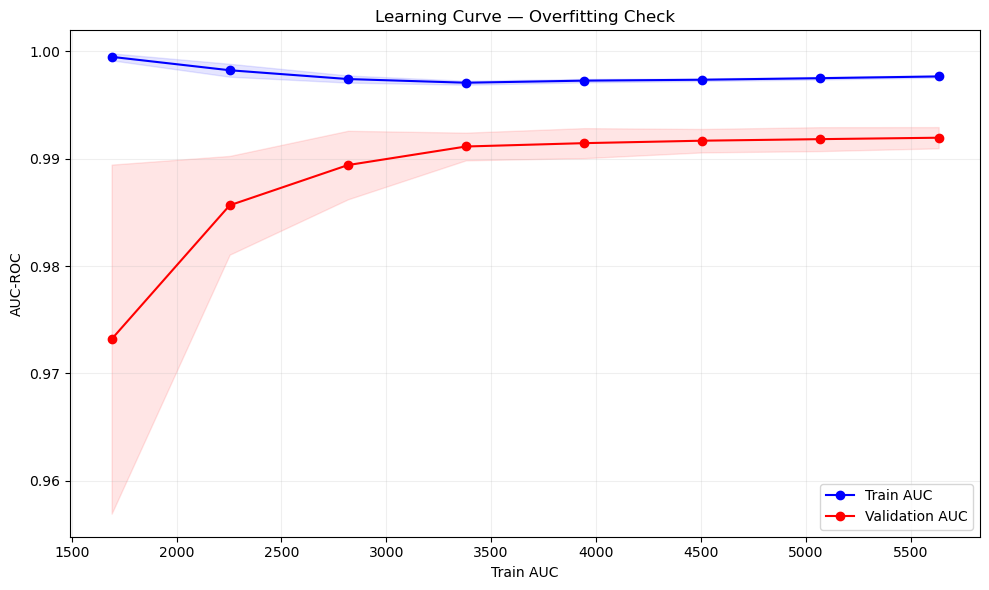

In [12]:
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train AUC')
plt.plot(train_sizes, val_mean, 'o-', color='red', label='Validation AUC')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')

plt.title('Learning Curve — Overfitting Check')
plt.xlabel('Train AUC')
plt.ylabel('AUC-ROC')
plt.legend(loc='lower right')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [13]:
ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()
all_feature_names = ohe_feature_names + list(numeric_cols)

coefficients = pipeline.named_steps['model'].coef_[0]
importance_df = pd.DataFrame({
    'Feature'      : all_feature_names,
    'Coefficient' : coefficients,
    'Abs_coef'     : np.abs(coefficients)
}).sort_values('Abs_coef', ascending=False)

print('=' * 50)
print('      Top 10 Features – Logistic Regression')
print('=' * 50)
print(importance_df[['Feature', 'Coefficient']].head(10).to_string(index=False))

      Top 10 Features – Logistic Regression
              Feature  Coefficient
   Satisfaction Score    -6.802727
  Online Security_Yes    -2.525720
  Number of Referrals    -2.086148
       Dependents_Yes    -2.027639
    Contract_Two Year    -1.884282
 Longitude_-121.55325     1.636251
Longitude_-117.969501     1.419776
Longitude_-119.825657     1.414097
Longitude_-122.037554     1.373244
Longitude_-122.286363     1.344533


In [14]:
X_train_transformed = pipeline.named_steps['preprocessor'].transform(X_train)
X_test_transformed  = pipeline.named_steps['preprocessor'].transform(X_test)

explainer = shap.LinearExplainer(
    pipeline.named_steps['model'],
    X_train_transformed,
    feature_names=all_feature_names
)
shap_values = explainer(X_test_transformed)

shap_df  = pd.DataFrame(np.abs(shap_values.values), columns=all_feature_names)
top5     = shap_df.mean().sort_values(ascending=False).head(5)
top5_idx = [all_feature_names.index(f) for f in top5.index]

print('=' * 50)
print('           Top 5 CHURN DRIVERS (SHAP)')
print('=' * 50)
for i, (feat, val) in enumerate(top5.items(), 1):
    print(f'  {i}. {feat:<35} {val:.4f}')
print('=' * 50)

           Top 5 CHURN DRIVERS (SHAP)
  1. Satisfaction Score                  5.4132
  2. Number of Referrals                 1.5673
  3. Online Security_Yes                 1.0357
  4. Dependents_Yes                      0.8017
  5. Contract_Two Year                   0.7547


In [15]:
background = '#0f1117'
panel      = '#1a1d27'
white      = '#ffffff'
gray       = '#888888'
colors     = ["#00ff40","#00eeff","#004cff","#d211eb","#6914c3"]

def style_ax(ax, title):
    ax.set_facecolor(panel)
    ax.set_title(title, color=white)
    ax.tick_params(colors=gray)
    for spine in ax.spines.values():
        spine.set_visible(False)

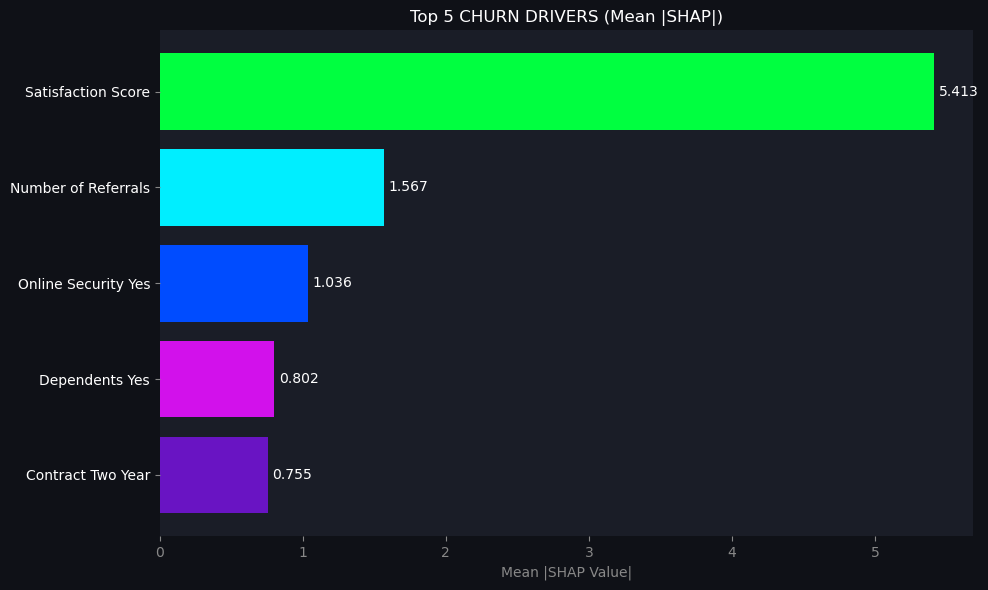

In [16]:
fig1, ax1 = plt.subplots(figsize=(10, 6))
fig1.patch.set_facecolor(background)
style_ax(ax1, 'Top 5 CHURN DRIVERS (Mean |SHAP|)')

labels = [f.replace('_', ' ') for f in top5.index[::-1]]
ax1.barh(range(5), top5.values[::-1], color=colors[::-1])
ax1.set_yticks(range(5))
ax1.set_yticklabels(labels, color=white)
ax1.set_xlabel('Mean |SHAP Value|', color=gray)
ax1.xaxis.label.set_color(gray)
ax1.tick_params(axis='x', colors=gray)

for i, v in enumerate(top5.values[::-1]):
    ax1.text(v + 0.03, i, f'{v:.3f}', va='center', color=white)

plt.tight_layout()
plt.show()

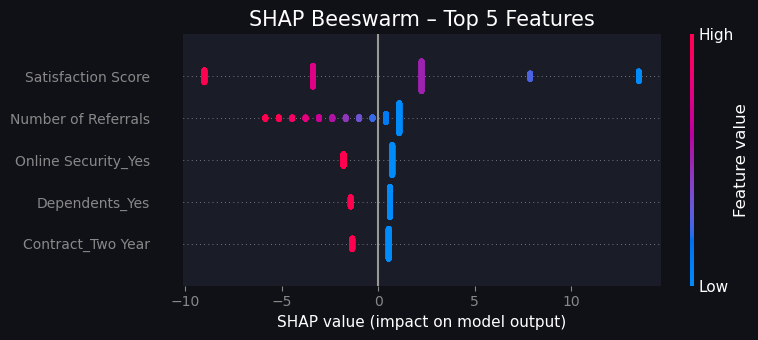

In [20]:
shap_top5 = shap_values[:, top5_idx]

fig2, ax2 = plt.subplots(figsize=(10, 6))
fig2.patch.set_facecolor(background)
ax2.set_facecolor(panel)
plt.sca(ax2)

shap.plots.beeswarm(shap_top5, max_display=5, show=False, color_bar=True)

ax2.set_facecolor(panel)
ax2.set_title('SHAP Beeswarm – Top 5 Features', color=white, fontsize=15)
ax2.set_xlabel('SHAP value (impact on model output)', color=white, fontsize=11)
ax2.tick_params(colors=gray, labelsize=10)
for spine in ax2.spines.values():
    spine.set_visible(False)
fig = plt.gcf()
axes = fig.get_axes()
cax = axes[-1]
cax.set_ylabel('Feature value', color=white)
cax.tick_params(colors=white)

plt.tight_layout()
plt.show()

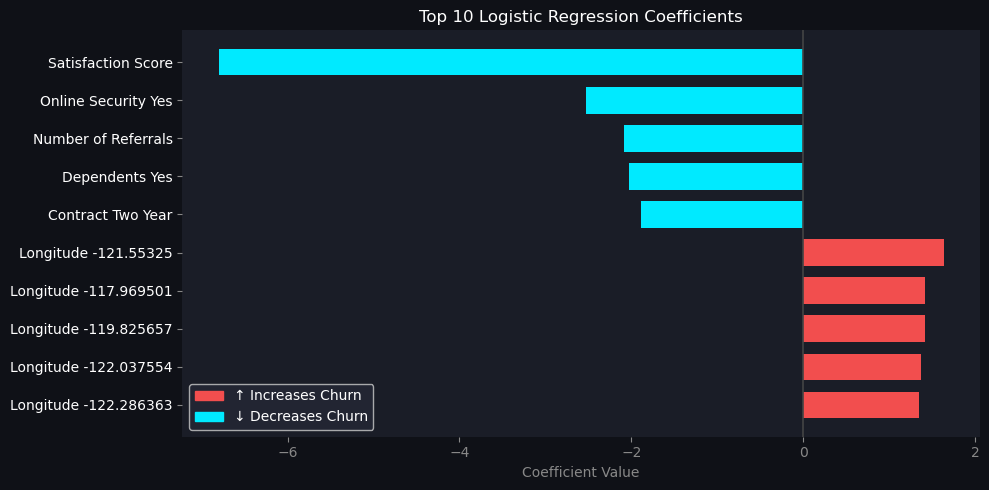

In [19]:
top10 = importance_df.head(10)
fig3, ax3 = plt.subplots(figsize=(10,5))
fig3.patch.set_facecolor(background)
style_ax(ax3, 'Top 10 Logistic Regression Coefficients')

bar_colors = ["#f24e4e" if c > 0 else "#00eaff" for c in top10['Coefficient'].values[::-1]]
ax3.barh(range(10), top10['Coefficient'].values[::-1], color=bar_colors, height=0.7)

labels10 = [f.replace('_', ' ')[:30] for f in top10['Feature'].values[::-1]]
ax3.set_yticks(range(10))
ax3.set_yticklabels(labels10, color=white)
ax3.set_xlabel('Coefficient Value', color=gray)
ax3.axvline(0, color='#444', linewidth=1.2)
ax3.tick_params(axis='x', colors=gray)

patch1 = mpatches.Patch(color='#f24e4e', label='↑ Increases Churn')
patch2 = mpatches.Patch(color='#00eaff', label='↓ Decreases Churn')
ax3.legend(handles=[patch1, patch2], facecolor='#252836',
           labelcolor=white, framealpha=0.8, loc='lower left')
plt.tight_layout()
plt.show()


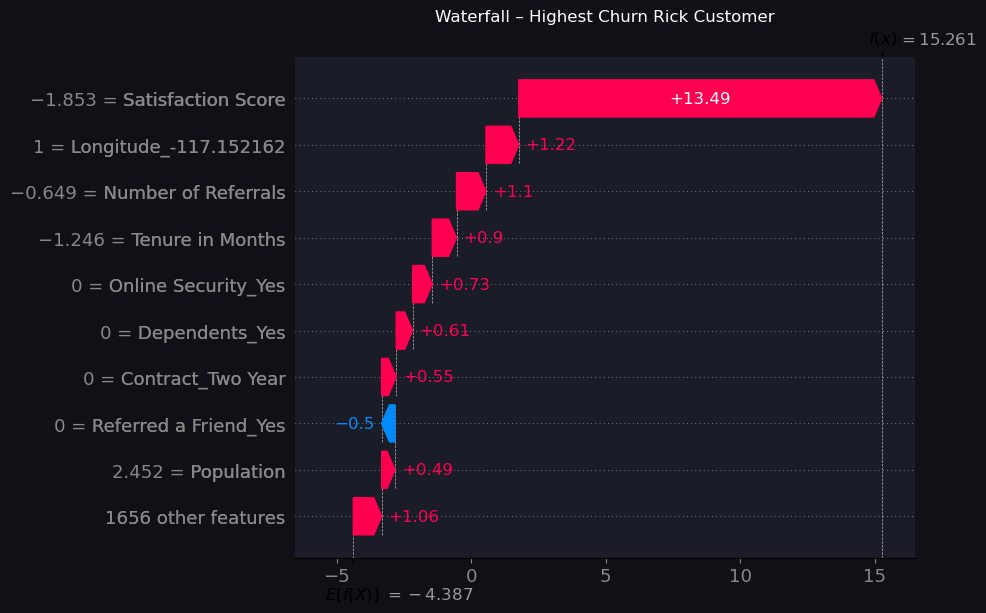

In [24]:
highest_idx = int(np.argmax(y_proba))

fig4, ax4 = plt.subplots(figsize=(10,5))
fig4.patch.set_facecolor(background)
ax4.set_facecolor(panel)
plt.sca(ax4)

shap.plots.waterfall(shap_values[highest_idx], max_display=10, show=False)

ax4.set_facecolor(panel)
ax4.set_title('Waterfall – Highest Churn Rick Customer', color=white)
ax4.tick_params(colors=gray)

plt.tight_layout
plt.show()